In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import lines as mlines
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

In [2]:
# Load Data
NGT_final = pd.read_parquet('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/NGT_filtered_STG_final.parquet')
metadata_filtered = pd.read_parquet('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/metadata_filtered_repeats_germline_freq.parquet')
metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0) 
annotations.index = annotations['variant_id']


/tmp/ipykernel_361246/3967599598.py:5: DtypeWarning: Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/Annotations_STG.csv', sep='\t', header=0)


In [3]:
axes_width = 2
label_size = 20
tick_size = 18
padding = 10

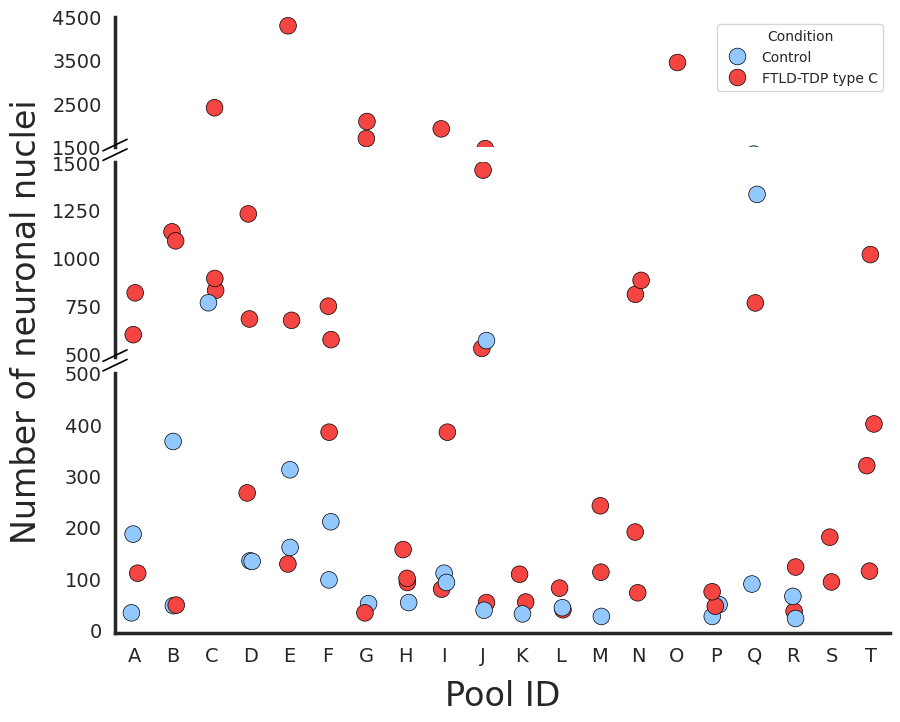

In [4]:
df = pd.DataFrame(metadata_filtered['ID'].value_counts())
df.columns = ['cell_count']
df['Sample_id'] = df.index

sample_metadata_path = '/results/rr/study/hg38s/study232-missionbio_TDP-C/data/metadata_hemisphere_PMI.csv'
sample_metadata = pd.read_csv(sample_metadata_path, sep=";")   
sample_metadata.set_index('Sample', inplace=True)
metadata = sample_metadata[sample_metadata['tissue'] == 'STG'].copy()
metadata["AGEATDEATH"] = (metadata["AGEATDEATH"].astype(str).str.replace(",", ".", regex=False))
metadata["AGEATDEATH"] = pd.to_numeric(metadata["AGEATDEATH"], errors="coerce")  
metadata["AGEATONSET"] = (metadata["AGEATONSET"].astype(str).str.replace(",", ".", regex=False))
metadata["AGEATONSET"] = pd.to_numeric(metadata["AGEATONSET"], errors="coerce") 

df['Condition'] = df.index.map(metadata['Group'])
# Drop the followig samples:
sample_not_stg = ["N1_P","Q4_P","Q5_P"]
condition = (df.index.isin(sample_not_stg))
df = df.drop(df.loc[condition].index, axis = 0)
df['Condition'] = df['Condition'].map({'FTLD-TDP C': 'FTLD-TDP type C', 'Control': 'Control'})
df['Pool'] = df['Sample_id'].str.split('_').str[0].str.extract(r'([A-Za-z]+)')
df = df.sort_values(by=['Pool'])

custom_palette = {
    'Control': "#92C7FF",
    'FTLD-TDP type C': "#F44542"
}

sns.set_style("white")

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(3, 1, height_ratios=[1, 1.5, 2], hspace=0.08)
ax_top = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1])
ax_bot = fig.add_subplot(gs[2])

for ax in [ax_top, ax_mid, ax_bot]:
    sns.stripplot(data=df, x='Pool', y='cell_count', hue='Condition',
                  palette=custom_palette, size=12, jitter=0.1,
                  edgecolor='black', linewidth=0.5, ax=ax, legend=(ax == ax_top))

# Y-axis limits and ticks
ax_top.set_ylim(1500, 4500)
ax_top.set_yticks([1500, 2500, 3500, 4500])

ax_mid.set_ylim(480, 1500)
ax_mid.set_yticks(range(500, 1501, 250))

ax_bot.set_ylim(-5, 500)
ax_bot.set_yticks(range(0, 501, 100))

# Spines
for ax in [ax_top, ax_mid, ax_bot]:
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines['left'].set_linewidth(2.5)
    ax.spines['bottom'].set_linewidth(2.5)
    ax.tick_params(axis='both', which='major', labelsize=14,
                   direction='out', length=6, width=1)

ax_top.spines['bottom'].set_visible(False)
ax_mid.spines[['top', 'bottom']].set_visible(False)
ax_bot.spines['top'].set_visible(False)

ax_top.tick_params(axis='x', labelbottom=False)
ax_mid.tick_params(axis='x', labelbottom=False)

# Break markers
d = 0.012
kwargs = dict(transform=fig.transFigure, color='k', clip_on=False, linewidth=1.2)

fig.canvas.draw()  
for break_pair in [(ax_top, ax_mid), (ax_mid, ax_bot)]:
    top_pos = break_pair[0].get_position()
    bot_pos = break_pair[1].get_position()
    break_y = (top_pos.y0 + bot_pos.y1) / 2
    x_pos = top_pos.x0
    for offset in [0, 0.012]:
        fig.add_artist(plt.Line2D([x_pos - d, x_pos + d],
                                   [break_y - d*0.6 + offset,
                                    break_y + d*0.6 + offset], **kwargs))

# Shared y-label
fig.text(0.02, 0.5, 'Number of neuronal nuclei', va='center',
         rotation='vertical', fontsize=24)

ax_bot.set_xlabel('Pool ID', fontsize=24, labelpad=10)

ax_top.set_ylabel('')
ax_top.set_xlabel('')
ax_mid.set_ylabel('')
ax_mid.set_xlabel('')
ax_bot.set_ylabel('')

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureC.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureC.svg", bbox_inches="tight", transparent=True)

plt.show()

In [5]:
out = pd.read_csv('/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/variant_frequencies_filtered_nonzero.tsv', sep="\t")
out.drop(columns=['Unnamed: 0'], inplace=True)
#Drop MTG and FC
out = out[~out['sample_id'].isin(['N1_P', 'Q4_P', 'Q5_C'])]
out[['REF', 'ALT']] = out['var'].str.split("/", expand=True)
out.index = out['variant_id']

In [6]:
# Select coding vars
def annotate_spliceai_effect(df: pd.DataFrame) -> pd.DataFrame:
    cols = ['SpliceAI_pred_DS_AG','SpliceAI_pred_DS_AL','SpliceAI_pred_DS_DG','SpliceAI_pred_DS_DL']
    labels = ['acceptor_gain', 'acceptor_loss','donor_gain','donor_loss']
    ds_matrix = (df[cols].apply(pd.to_numeric, errors='coerce').fillna(0).to_numpy())
    max_idx = ds_matrix.argmax(axis=1)
    max_score = ds_matrix.max(axis=1)

    # Map severity
    severity = np.select(
        [max_score >= 0.8,max_score >= 0.5,max_score >= 0.2],
        ['high','moderate','low'],
        default='none'
    )

    # Map effect
    effect = [labels[i] for i in max_idx]
    # If all four scores are 0 → effect should be none
    effect = np.where(max_score == 0, 'none', effect)
    df['spliceai_severity'] = severity
    df['spliceai_effect'] = effect

    return df

def categorize_hc_lof(row) -> str:
    lof_flag = str(row.get("LoF", "")).upper()
    spliceai_sev = str(row.get("spliceai_severity", "")).lower()
    if lof_flag in {"HC", "OS"} or spliceai_sev == "high":
        return "Yes"
    return np.nan

output_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data"

LOF = {
    "stop_gained", "frameshift_variant", "stop_gained&frameshift_variant",
    "splice_acceptor_variant", "splice_donor_variant",
    "stop_gained&splice_region_variant", "frameshift_variant&splice_region_variant"
}

indel_terms = [
    "frameshift_variant",
    "frameshift_variant&splice_region_variant",
    "stop_gained&frameshift_variant",
    "stop_gained&inframe_deletion",
    "inframe_deletion",
    "inframe_insertion",
    "frameshift_variant&stop_lost",
    "frameshift_variant&start_lost",
]

non_coding_terms = [
    "intron_variant",
    "splice_polypyrimidine_tract_variant&intron_variant",
    "splice_region_variant&splice_polypyrimidine_tract_variant&intron_variant",
    "splice_donor_region_variant&intron_variant",
    "splice_region_variant&5_prime_UTR_variant",
    "splice_donor_5th_base_variant&intron_variant",
    "splice_region_variant&intron_variant",
    "3_prime_UTR_variant",
    "5_prime_UTR_variant",
    # "splice_acceptor_variant", "splice_donor_variant"
]

splice_site_terms = ["splice_acceptor_variant", "splice_donor_variant"]
missense_terms = ["missense_variant", "missense_variant&splice_region_variant"]
nonsense_terms = ["stop_gained", "stop_gained&splice_region_variant", "stop_gained&frameshift_variant", "stop_gained&inframe_deletion"]
frameshift_terms = ["frameshift_variant", "frameshift_variant&splice_region_variant", "frameshift_variant&stop_lost", "frameshift_variant&start_lost"]
synonymous_terms = ['synonymous_variant', 'stop_retained_variant', 'splice_region_variant&synonymous_variant']
nonsynonymous_terms = [
    "start_lost",
    "missense_variant",
    "frameshift_variant",
    "stop_gained",
    "missense_variant&splice_region_variant",
    "inframe_deletion",
    "frameshift_variant&splice_region_variant",
    "inframe_insertion",
    "stop_gained&splice_region_variant",
    "stop_lost",
    "stop_gained&frameshift_variant",
    "frameshift_variant&stop_lost",
    "stop_gained&inframe_deletion",
    "frameshift_variant&start_lost",
]

parquet_dir = "/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/parquets/"
AF_FILTERED = pd.read_parquet(f"{parquet_dir}AF_filtered_STG_final.parquet")
DP = pd.read_parquet(f"{parquet_dir}DP_filtered_STG_final.parquet")
metadata_filtered = pd.read_parquet(f"{parquet_dir}metadata_filtered_repeats_germline_freq.parquet")
GQ = pd.read_parquet(f"{parquet_dir}GQ_filtered_STG_final.parquet")
NGT_final = pd.read_parquet(f"{parquet_dir}NGT_filtered_STG_final.parquet")

metadata_filtered['age_at_death'] = metadata_filtered['age_at_death'].astype(str).str.replace(',', '.', regex=False)
metadata_filtered = metadata_filtered.loc[NGT_final.index]

# Load annotations
annotations = pd.read_csv('/results/rr/study/hg38s/study232-missionbio_TDP-C/outputs/vaf30/Annotations_vafhet30.csv', sep='\t', header=0) 
annotations['Protein_annotation'] = annotations['HGVSp'].str.split(".", expand=True)[2]
annotations = annotations[annotations['variant_id'].isin(NGT_final.columns)]
annotate_spliceai_effect(annotations)

genes = ["TARDBP", "TET2", "TMEM106B", "OPTN", "TBK1", "GRN", "UNC13A"]
annotations_df = []
NGT_list_filtered = []
NGT_patients_list = []
NGT_controls_list = []

ann_all_vars_list = []
ann_all_snv_list = []
ann_all_indels_list = []

ann_coding_list = []
ann_indels_list = []
ann_snv_list = []

ann_nonsyn_list = []
ann_syn_list = []
ann_missense_list = []
ann_nonsense_list = []
ann_frameshift_list = []
ann_splicesite_list = []
ann_startloss_list = []
ann_stoploss_list = []
cadd_above20_list = []
ann_LOF_list = []
ann_HC_LOF_list = []


var_groups_dict = {}
burden_dict = {}
var_groups_names = [
    "Coding_variants", "SNVs", "Indels", "Synonymous",
    "Non_synonymous", "Missense", "Nonsense",
    "Frameshift", "Splice site", "LOF", "HC_LOF", "CADD_atleast20",
]

for i, gene_name in enumerate(genes):
    ann = annotations[annotations['SYMBOL']==gene_name].copy()
    ann.index = ann['variant_id']
    ann["HC_LOF"] = ann.apply(categorize_hc_lof,  axis=1)
    ann = ann.set_index('variant_id')

    vars = ann.index.tolist()
    NGT = NGT_final.loc[:, vars].copy()
    #print("Number of variants per bp covered:", np.round(NGT.shape[1]/genes_bp[i], 3))
    meta = metadata_filtered.reindex(NGT.index).copy()

    NGT = NGT.assign(
        sample_identifier = meta['ID'],
        sample_id         = meta['sample_id'],
        sample_type       = meta['sample_type'],
        age_at_death      = meta['age_at_death'].to_numpy(),
        age_at_onset      = meta['age_at_onset'].to_numpy(),
        hemisphere        = meta['hemisphere'],
    )
    NGT_list_filtered.append(NGT)
    
    NGT_controls = NGT[NGT['sample_type'] == "C"]
    NGT_patients = NGT[NGT['sample_type'] == "P"]

    counts = pd.DataFrame({
        "cell_count_patients": NGT_patients.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_P": NGT_patients.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts["mutation_freq_P"] = counts["cell_count_patients"] / counts["total_genotyped_cells_P"] * 100
    ann = ann.merge(counts, left_index=True, right_index=True, how="inner")

    counts_C = pd.DataFrame({
        "cell_count_controls": NGT_controls.iloc[:, :-6].isin([1, 2]).sum(),
        "total_genotyped_cells_C": NGT_controls.iloc[:, :-6].isin([0, 1, 2]).sum()
    })
    counts_C["mutation_freq_C"] = counts_C["cell_count_controls"] / counts_C["total_genotyped_cells_C"] * 100
    ann = ann.merge(counts_C, left_index=True, right_index=True, how="inner")
    ann["total_cells"] = ann["cell_count_patients"] + ann["cell_count_controls"]
    ann["total_genotyped_cells"] = ann['total_genotyped_cells_P'] + ann['total_genotyped_cells_C']
    ann['total_freq'] = ann["total_cells"]/ann['total_genotyped_cells']*100

    annotations_df.append(ann)
    NGT_patients_list.append(NGT_patients)
    NGT_controls_list.append(NGT_controls)

    lengths_ref = ann['REF'].apply(len)
    length_alt = ann['ALT'].apply(len)
    indels = (lengths_ref[lengths_ref >1].index.to_list()) + (length_alt[length_alt >1].index.to_list()) # Count total number of indels
    indels = list(set(indels))
    ann_all_snv = ann.drop(index = indels) # To calculate total number of SNVs
    ann_all_indels = ann.loc[indels]

    ann_coding = ann[~ann['Consequence'].isin(non_coding_terms)]
    ann_indel = ann_coding[ann_coding['Consequence'].isin(indel_terms)] #Indels in coding regions 
    ann_snv = ann_coding[~ann_coding['Consequence'].isin(indel_terms)] # SNVs in coding regions
    
    ann_nonsyn = ann_coding[ann_coding['Consequence'].isin(nonsynonymous_terms)]
    ann_syn = ann_coding[ann_coding['Consequence'].isin(synonymous_terms)]
    ann_missense = ann_coding[ann_coding['Consequence'].isin(missense_terms)]
    ann_nonsense = ann_coding[ann_coding['Consequence'].isin(nonsense_terms)]
    ann_frameshift = ann_coding[ann_coding['Consequence'].isin(frameshift_terms)]
    ann_splicesite = ann_coding[ann_coding['Consequence'].isin(splice_site_terms)]
    ann_startloss = ann_coding[ann_coding['Consequence'].isin(["start_lost"])]
    ann_stoploss = ann_coding[ann_coding['Consequence'].isin(["stop_lost"])]
    ann_lof = ann_coding[ann_coding['Consequence'].isin(list(LOF))]
    ann_lof_hf = ann_lof[ann_lof['HC_LOF']=="Yes"]
    cadd_above20 = ann_snv[ann_snv['CADD_PHRED'] >= 20]

    ann_all_vars_list.append(ann)
    ann_all_snv_list.append(ann_all_snv)
    ann_all_indels_list.append(ann_all_indels)
    ann_snv_list.append(ann_snv)
    ann_indels_list.append(ann_indel)
    ann_coding_list.append(ann_coding)
    ann_nonsyn_list.append(ann_nonsyn)
    ann_syn_list.append(ann_syn)

    ann_missense_list.append(ann_missense)
    ann_nonsense_list.append(ann_nonsense)
    ann_frameshift_list.append(ann_frameshift)
    ann_splicesite_list.append(ann_splicesite)
    ann_startloss_list.append(ann_startloss)
    ann_stoploss_list.append(ann_stoploss)
    ann_LOF_list.append(ann_lof)
    ann_HC_LOF_list.append(ann_lof_hf)
    cadd_above20_list.append(cadd_above20)

    var_groups_dict[gene_name] = {
        group_name: group_list[i]
        for group_name, group_list in zip(
            var_groups_names,
            [
                ann_coding_list,
                ann_snv_list,
                ann_indels_list,
                ann_syn_list,
                ann_nonsyn_list,
                ann_missense_list,
                ann_nonsense_list,
                ann_frameshift_list,
                ann_splicesite_list,
                ann_LOF_list,
                ann_HC_LOF_list,
                cadd_above20_list

            ]
        )
    }

    df = NGT.copy()
    ids_selected = df['sample_id'].unique()
    list_vars = var_groups_dict[gene_name]
    

/tmp/ipykernel_361246/789251649.py:97: DtypeWarning: Columns (37,39,76) have mixed types. Specify dtype option on import or set low_memory=False.
  annotations = pd.read_csv('/results/rr/study/hg38s/study232-missionbio_TDP-C/outputs/vaf30/Annotations_vafhet30.csv', sep='\t', header=0)


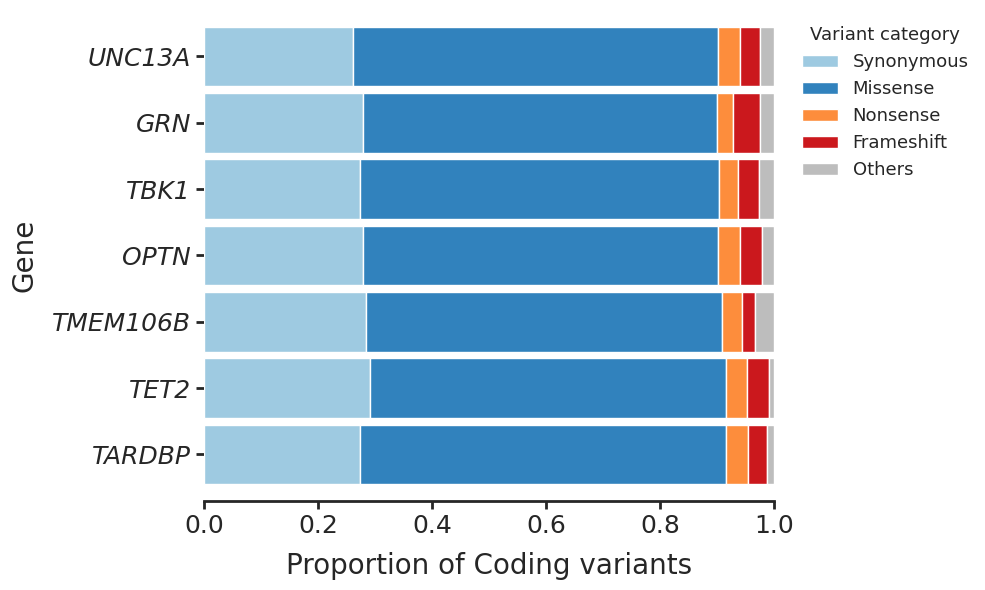

In [ ]:
colors = {
    "Synonymous": "#9ecae1",
    "Missense":   "#3182bd",
    "Nonsense":   "#fd8d3c",
    "Frameshift": "#cb181d",
    "Others":     "#bdbdbd"
}

rows = []
for gene, groups in var_groups_dict.items():
    coding = len(groups["Coding_variants"])
    syn = len(groups["Synonymous"])
    mis = len(groups["Missense"])
    non = len(groups["Nonsense"])
    fs  = len(groups["Frameshift"])
    others = coding - (syn + mis + non + fs)

    rows.append({
        "Gene": gene,
        "Synonymous": syn,
        "Missense": mis,
        "Nonsense": non,
        "Frameshift": fs,
        "Others": others
    })

df = pd.DataFrame(rows).set_index("Gene")
df_prop = df.div(df.sum(axis=1), axis=0)

ax = df_prop.plot(
    kind="barh",
    stacked=True,
    width=0.9,
    figsize=(10,6),
    color=[colors[col] for col in df.columns]
)

plt.xlabel("Proportion of Coding variants", size =label_size, labelpad=padding)
plt.ylabel("Gene", size =label_size, labelpad=padding)
ax.set_xlim(0, 1)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.legend(
    title="Variant category",
    loc="upper left",
    bbox_to_anchor=(1.02, 1.0),
    frameon=False,
    fontsize=13,
    title_fontsize=13
)

ax.tick_params(axis="x",which="major",bottom=True,top=False,length=6,width=axes_width,direction="out", labelsize=tick_size)
ax.tick_params(axis="y", which="major", left=True, right=False,length=6, width=axes_width, direction="out", labelsize=tick_size)

for spine in ax.spines.values():
    spine.set_linewidth(axes_width)

for label in ax.get_yticklabels():
    label.set_style('italic')

plt.tight_layout()

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureD.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureD.svg", bbox_inches="tight", transparent=True)

plt.show()

In [8]:
#Number of coding variants 
all_coding_vars  = []
for i in range(len(ann_coding_list)):
    all_coding_vars.extend(ann_coding_list[i].index.to_list())
print(len(all_coding_vars))

all_coding_snvs  = []
for i in range(len(ann_snv_list)):
    all_coding_snvs.extend(ann_snv_list[i].index.to_list())
print(len(all_coding_snvs))

all_coding_indels  = []
for i in range(len(ann_indels_list)):
    all_coding_indels.extend(ann_indels_list[i].index.to_list())
print(len(all_coding_indels))



19102
18377
725


In [9]:
variant_counts = NGT_final[all_coding_vars].isin([1, 2]).sum(axis=0)
counts = pd.Series(variant_counts).value_counts().sort_index()

nuclei_counts = NGT_final[all_coding_vars].isin([1, 2]).sum(axis=1)
nuclei_counts = pd.Series(nuclei_counts).value_counts().sort_index()

In [10]:
# Number of coding variants per nucleus
print("Median:", NGT_final[all_coding_vars].isin([1, 2]).sum(axis=1).median())
print("Mean:", np.round(NGT_final[all_coding_vars].isin([1, 2]).sum(axis=1).mean(), 2))

Median: 2.0
Mean: 2.26


In [11]:
#Nuclei with at least one coding variant
print("Percentage of nuclei with at least one coding variant:", np.round(((NGT_final.shape[0] - nuclei_counts.iloc[0])/ NGT_final.shape[0] )*100, 2))
print("Nuclei with no coding variants:", nuclei_counts.iloc[0])

Percentage of nuclei with at least one coding variant: 84.28
Nuclei with no coding variants: 6258


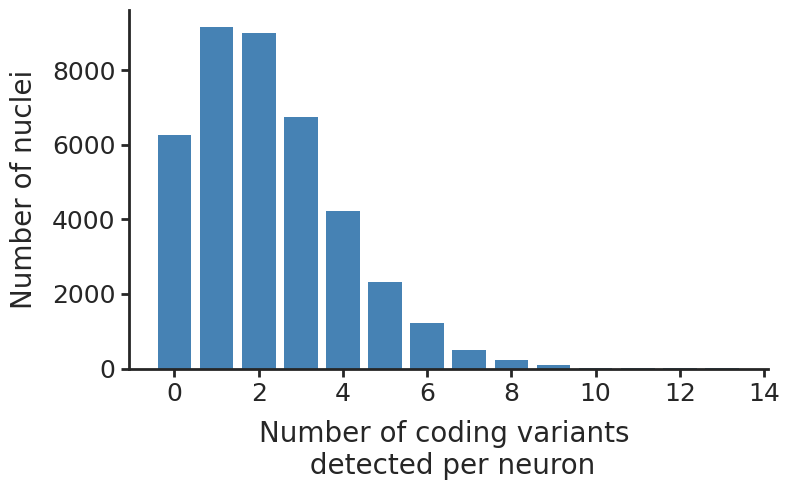

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(nuclei_counts.index, height=nuclei_counts.values,
       color="steelblue", edgecolor="none")

sns.despine(top=True, right=True)
ax.set_xlabel("Number of coding variants \n detected per neuron",
              size=label_size, labelpad=padding)
ax.set_ylabel("Number of nuclei", size=label_size, labelpad=padding)
ax.tick_params(axis="x", which="both", bottom=True, top=False,length=6, width=axes_width, direction="out", labelsize=tick_size)
ax.tick_params(axis="y", which="major", left=True, right=False,length=6, width=axes_width, direction="out", labelsize=tick_size)

for spine in ax.spines.values():
    spine.set_linewidth(axes_width)

plt.tight_layout()
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureE.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureE.svg", bbox_inches="tight", transparent=True)

plt.show()

In [13]:
# Number of samples affected by each variant
# count how many samples each variant appears in

out_coding = out[out['variant_id'].isin(all_coding_vars)].copy()
variant_sample_counts = (
    out_coding.reset_index(drop=True)          
    .groupby("variant_id")["sample_id"]
    .nunique()
    .reset_index()
    .rename(columns={"sample_id": "n_samples"})
)

distribution = (
    variant_sample_counts["n_samples"]
    .value_counts()
    .sort_index()
    .reset_index()
    .rename(columns={"index": "n_samples", "n_samples": "n_variants"})
)

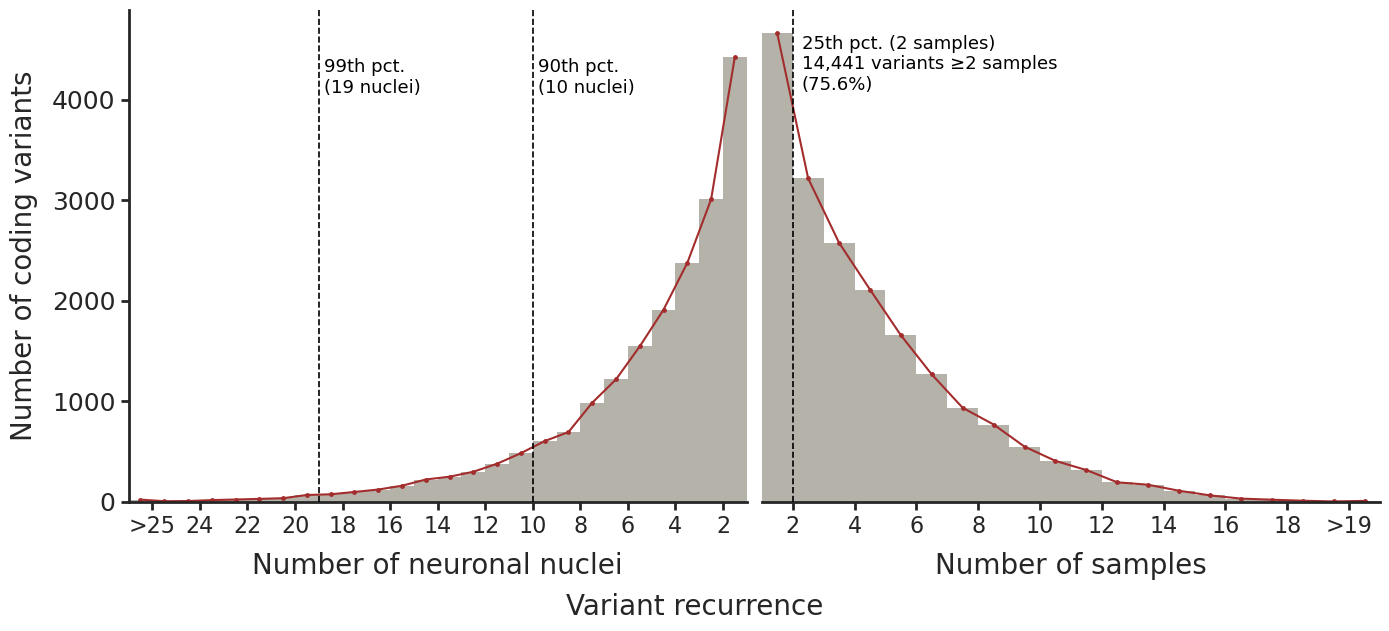

In [ ]:
# --- Number of nuclei ---
cutoff1 = 25
raw1 = np.repeat(counts.index, counts.values)
p90  = np.percentile(raw1, 90)
p99  = np.percentile(raw1, 99)
raw1_clipped = np.where(raw1 > cutoff1, cutoff1 + 1, raw1)
bins1 = list(range(0, cutoff1 + 3))

# --- Number of sampples ---
cutoff2 = 19
raw2 = np.repeat(distribution["n_samples"], distribution["n_variants"])
p25  = np.percentile(raw2, 25)
n_above_1   = (raw2 > 1).sum()
pct_above_1 = n_above_1 / len(raw2) * 100
raw2_clipped = np.where(raw2 > cutoff2, cutoff2 + 1, raw2)
bins2 = list(range(0, cutoff2 + 3))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.subplots_adjust(wspace=0)

# Plot
n1, bin_edges1, _ = ax1.hist(raw1_clipped, bins=bins1,
                              color="#B4B2A9", edgecolor="none")
bc1   = 0.5 * (bin_edges1[:-1] + bin_edges1[1:])
mask1 = (bc1 >= 1) & (bc1 <= cutoff1 + 1.5)
ax1.plot(bc1[mask1], n1[mask1], color="#A32D2D", linewidth=1.5,
         marker="o", markersize=3.5,
         markerfacecolor="#A32D2D", markeredgewidth=0)

ax1.axvline(x=p90, color="black", linewidth=1.2, linestyle="--", zorder=3)
ax1.text(p90 - 0.2, ax1.get_ylim()[1] * 0.95,
         f"90th pct.\n({p90:.0f} nuclei)",
         color="black", fontsize=13, va="top")
ax1.axvline(x=p99, color="black", linewidth=1.2, linestyle="--", zorder=3)
ax1.text(p99 - 0.2, ax1.get_ylim()[1] * 0.95,
         f"99th pct.\n({p99:.0f} nuclei)",
         color="black", fontsize=13, va="top")

ax1.invert_xaxis()
ax1.set_xlim(cutoff1 + 2, 1)
ticks1  = list(range(2, cutoff1 + 1, 2)) + [cutoff1 + 1]
labels1 = [str(t) for t in range(2, cutoff1 + 1, 2)] + [f">{cutoff1}"]
ax1.set_xticks(ticks1)
ax1.set_xticklabels(labels1)
ax1.set_ylabel("Number of coding variants", size=label_size, labelpad=padding)

n2, bin_edges2, _ = ax2.hist(raw2_clipped, bins=bins2,
                              color="#B4B2A9", edgecolor="none")
bc2   = 0.5 * (bin_edges2[:-1] + bin_edges2[1:])
mask2 = (bc2 >= 1) & (bc2 <= cutoff2 + 1.5)
ax2.plot(bc2[mask2], n2[mask2], color="#A32D2D", linewidth=1.5,
         marker="o", markersize=3.5,
         markerfacecolor="#A32D2D", markeredgewidth=0)

ax2.axvline(x=p25, color="black", linewidth=1.2, linestyle="--", zorder=3)
ax2.text(p25 + 0.3, ax2.get_ylim()[1] * 0.95,
         f"25th pct. ({p25:.0f} samples)\n{n_above_1:,} variants ≥2 samples\n({pct_above_1:.1f}%)",
         color="black", fontsize=13, va="top")

ax2.set_xlim(1, cutoff2 + 2)
ticks2  = list(range(2, cutoff2 + 1, 2)) + [cutoff2 + 1]
labels2 = [str(t) for t in range(2, cutoff2 + 1, 2)] + [f">{cutoff2}"]
ax2.set_xticks(ticks2)
ax2.set_xticklabels(labels2)
ax2.tick_params(labelleft=False)

# Shared formatting
for ax in [ax1, ax2]:
    sns.despine(ax=ax, top=True, right=True)
    ax.tick_params(axis="x", which="major", bottom=True, top=False,length=6, width=axes_width, direction="out", labelsize = 16)
    ax.tick_params(axis="y", which="major", left=True, right=False,length=6, width=axes_width, direction="out", labelsize = tick_size)
    ax.spines['left'].set_linewidth(axes_width)
    ax.spines['bottom'].set_linewidth(axes_width)

ax1.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(left=False)

# Main x-axis label
fig.text(0.5, -0.02, "Variant recurrence", ha="center", va="center",
         fontsize=label_size, fontweight="normal")

# Individual x-axis labels
ax1.set_xlabel("Number of neuronal nuclei", size=label_size, labelpad=padding)
ax2.set_xlabel("Number of samples", size=label_size, labelpad=padding)
plt.tight_layout()
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureF.png", dpi= 600, bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureF.svg", bbox_inches="tight", transparent=True)
plt.show()

In [15]:
def plot_variant_freq_by_sample(
    df,
    id_column='ID',
    freq_col='frequency',
    cell_count_col='total_cells',
    jitter=0.01,
    sample_order=None,
    point_color='#444444',
    ax=None
):
    d = df.copy()
    samples = list(sample_order)

    if ax is None:
        fig, ax = plt.subplots(figsize=(18, 7))
    else:
        fig = ax.figure

    ax2 = ax.twinx()

    cell_counts = (
        d.groupby(id_column)[cell_count_col]
        .first()
        .reindex(samples)
        .fillna(0)
    )
    ax2.bar(range(len(samples)), cell_counts.values,
            color='steelblue', alpha=0.15, width=0.8, zorder=0)
    ax2.set_ylabel('Total neuronal nuclei', color='black',
                   fontsize=label_size, labelpad=30, rotation=270)
    ax2.tick_params(axis='y', labelcolor='black', labelsize=tick_size, length=7, width=1.5)
    ax2.spines['top'].set_visible(False)

    # scatter points
    for i, sample in enumerate(samples):
        g = d[d[id_column] == sample]
        if g.empty:
            continue
        x = np.random.normal(loc=i, scale=jitter, size=len(g))
        ax.scatter(x, g[freq_col].to_numpy(), s=10, c=point_color, zorder=2)

    ax.set_xticks(range(len(samples)))
    ax.set_xticklabels(samples, rotation=90)
    ax.set_xlabel('Sample ID', fontsize=label_size, labelpad=padding)
    ax.set_ylabel('Variant frequency (%)', fontsize=label_size, labelpad=padding)
    ax.tick_params(axis='x', which='both', bottom=True, top=False,
                   length=7, width=1.5, direction='out', labelsize=tick_size-4)
    ax.tick_params(axis='y', which='major', left=True, right=False,
                   length=7, width=1.5, direction='out', labelsize=tick_size)
    ax.spines['top'].set_visible(False)

    ax.set_zorder(ax2.get_zorder() + 1)
    ax.patch.set_visible(False)

    for spine in ax.spines.values():
        spine.set_linewidth(2)
    for spine in ax2.spines.values():
        spine.set_linewidth(2)

    fig.tight_layout()
    return fig, ax, samples

In [16]:
meta = metadata_filtered.reindex(NGT_final.index).copy()
NGT_final = NGT_final.assign(sample_identifier = meta['ID'])
total_cells = pd.DataFrame(NGT_final['sample_identifier'].value_counts())
sample_order = total_cells.sort_values('sample_identifier', ascending=True).index.tolist()

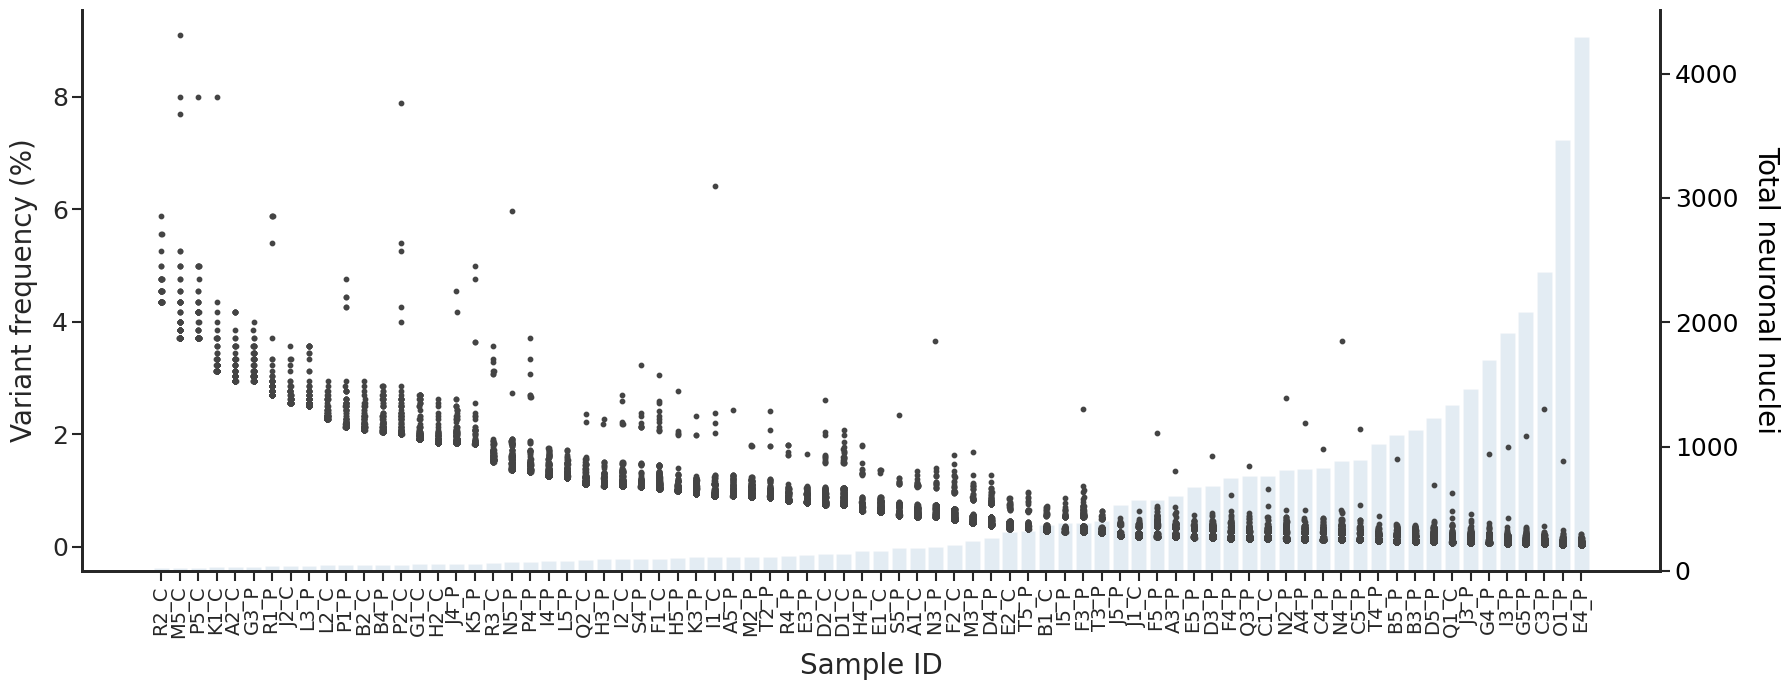

In [ ]:
fig, ax, _ = plot_variant_freq_by_sample(
        out_coding,
        id_column='ID',
        freq_col='frequency',
        sample_order=sample_order,
        cell_count_col='n_cells_total',
    )

plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureG.svg", bbox_inches="tight", transparent=True)
plt.savefig("/home/AD/vbidhan/study232-missionbio_TDP-C/manuscript_data/figures/panels/panel1/figureG.png", dpi=600, bbox_inches="tight", transparent=True)